In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import models, layers
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import joblib
import numpy as np

In [2]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "C:/Fruit_Fresh_pro/dataset_split/train/banana",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "C:/Fruit_Fresh_pro/dataset_split/val/banana",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ✅ Print class names (label mapping)
print("Class labels:", train_ds.class_names)

train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds   = val_ds.map(lambda x, y: (x/255.0, y))

Found 2200 files belonging to 3 classes.
Found 460 files belonging to 3 classes.
Class labels: ['Fresh', 'Rotten', 'premium']


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(128,128,3))

x = layers.Conv2D(32, (3,3), padding="same")(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(64, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(128, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.GlobalAveragePooling2D()(x)

features = layers.Dense(128, activation='relu', name="features")(x)
features = layers.BatchNormalization()(features)
features = layers.Dropout(0.4)(features)

outputs = layers.Dense(3, activation='softmax')(features)

cnn_classifier = Model(inputs, outputs)

In [4]:
cnn_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [5]:
history = cnn_classifier.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15)

Epoch 1/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 37s 477ms/step - accuracy: 0.7264 - loss: 0.7182 - val_accuracy: 0.4348 - val_loss: 1.0428
Epoch 2/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 40s 458ms/step - accuracy: 0.8505 - loss: 0.4393 - val_accuracy: 0.4348 - val_loss: 0.9893
Epoch 3/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.8755 - loss: 0.3623 - val_accuracy: 0.6913 - val_loss: 0.9016
Epoch 4/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 31s 451ms/step - accuracy: 0.9009 - loss: 0.2918 - val_accuracy: 0.7457 - val_loss: 0.7521
Epoch 5/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 32s 459ms/step - accuracy: 0.9068 - loss: 0.2995 - val_accuracy: 0.6652 - val_loss: 0.7187
Epoch 6/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.9068 - loss: 0.2645 - val_accuracy: 0.8109 - val_loss: 0.4680
Epoch 7/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 42s 469ms/step - accuracy: 0.9114 - loss: 0.2531 - val_accuracy: 0.8870 - val_loss: 0.3241
Epoch 8/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 41s 467ms/step - accuracy: 0.9195 - loss: 0.2425 - val_accu

In [6]:
cnn_classifier.save("C:/Fruit_Fresh_pro/model/banana_CNN.h5")

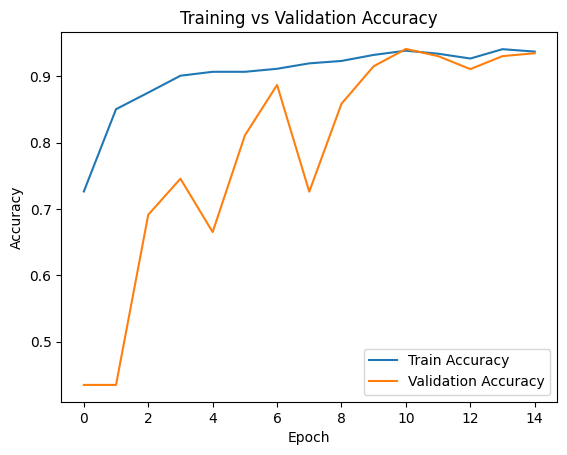

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

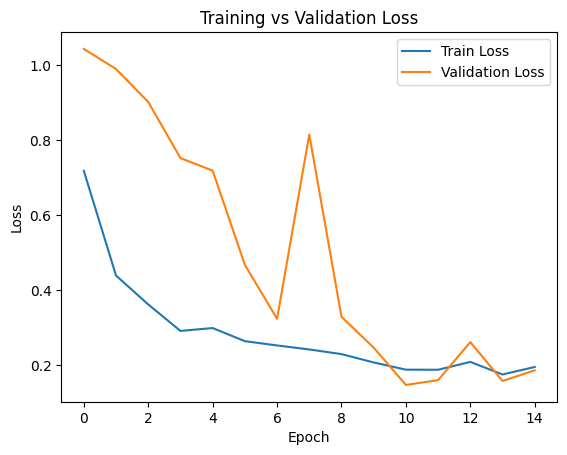

In [8]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [9]:
cnn_classifier.trainable = False

In [10]:
cnn_feature_extractor = Model(
    inputs=cnn_classifier.input,
    outputs=cnn_classifier.get_layer("features").output
)

In [11]:
import numpy as np

def extract_features(ds):
    X, y = [], []
    for images, labels in ds:
        feats = cnn_feature_extractor(images, training=False)
        X.append(feats.numpy())
        y.append(labels.numpy())
    return np.vstack(X), np.concatenate(y)

X_train, y_train = extract_features(train_ds)
X_val, y_val     = extract_features(val_ds)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C=1.0))
])

svm_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


In [13]:
y_pred = svm_model.predict(X_val)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = svm_model.predict(X_val)

print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       200
           1       0.98      0.94      0.96       200
           2       0.97      1.00      0.98        60

    accuracy                           0.97       460
   macro avg       0.97      0.97      0.97       460
weighted avg       0.97      0.97      0.97       460

[[195   3   2]
 [ 11 189   0]
 [  0   0  60]]


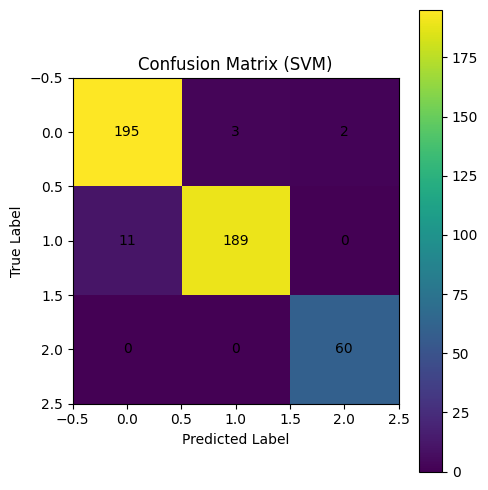

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import accuracy_score

y_pred = svm_model.predict(X_val)
hybrid_acc = accuracy_score(y_val, y_pred)

print("Hybrid CNN + SVM Accuracy:",round(hybrid_acc * 100),"%")

Hybrid CNN + SVM Accuracy: 97 %


In [20]:
from joblib import dump

# svm_model = your trained SVM
dump(svm_model, "C:/Fruit_Fresh_pro/model/svm_banana_new.pkl")

print("SVM model saved successfully!")

SVM model saved successfully!


In [21]:
from joblib import load

svm_model = load("C:/Fruit_Fresh_pro/model/svm_banana_new.pkl")

print("SVM model loaded successfully!")

SVM model loaded successfully!


In [22]:
from PIL import Image
import numpy as np

def extract_features_from_image(img_path, img_size=128):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_size, img_size))
    img = np.array(img) / 255.0

    img = np.expand_dims(img, axis=0)   # (1, 128, 128, 3)

    features = cnn_feature_extractor(img, training=False)
    return features.numpy()

In [24]:
img_path = r"C:/Fruit_Fresh_pro/random/good.jpg"

features = extract_features_from_image(img_path)
print(features.shape)

(1, 128)


In [25]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# img_scaled   = scaler.fit_transform(features)

In [26]:
prediction = svm_model.predict(features)
print(prediction)

[2]


In [28]:
random_folder = r"C:/Fruit_Fresh_pro/random/random_banana/"
import os 

for file in os.listdir(random_folder):
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(random_folder, file)

        # 1️⃣ Extract CNN features
        features = extract_features_from_image(img_path)
        print(f"{file} → feature shape:", features.shape)

        # 2️⃣ Scale features
        # img_scaled = scaler.transform(features)

        # 3️⃣ SVM prediction
        prediction = svm_model.predict(features)[0]

        # 4️⃣ Print result
        print(f"{file} → Predicted class: {prediction}")
        print("-" * 50)

28-283985_feelingkind-of-rotten-saba-banana-removebg-preview (1).png → feature shape: (1, 128)
28-283985_feelingkind-of-rotten-saba-banana-removebg-preview (1).png → Predicted class: 0
--------------------------------------------------
360_F_132544465_ID5anYjFCTlamH9pCZ4Fb5FBvPXO9MdI.jpg → feature shape: (1, 128)
360_F_132544465_ID5anYjFCTlamH9pCZ4Fb5FBvPXO9MdI.jpg → Predicted class: 0
--------------------------------------------------
360_F_44038854_YLWPOf5Bb4fG8TxyJj766H7jNHHhlBSA.jpg → feature shape: (1, 128)
360_F_44038854_YLWPOf5Bb4fG8TxyJj766H7jNHHhlBSA.jpg → Predicted class: 1
--------------------------------------------------
556_EFHd.jpg → feature shape: (1, 128)
556_EFHd.jpg → Predicted class: 2
--------------------------------------------------
single-banana-11528333488mo37mzhq8r.png → feature shape: (1, 128)
single-banana-11528333488mo37mzhq8r.png → Predicted class: 2
--------------------------------------------------
